# Seasonal Agriculture Performance Analysis

## 1. Problem Statement

Agricultural activities are influenced by seasonal variations in environmental conditions, farming practices, resource availability and economic conditions. As a result, agricultural performance may differ from one season to another.

The objective of this project is to analyze the given agricultural dataset and investigate seasonal differences in agricultural performance by identifying meaningful patterns, trends, relationships and variations within the available data.

This notebook explores the dataset, applies data cleaning and statistical analysis, creates visualizations, and develops evidence-based findings and recommendations.

## 2. Project Objectives

- Understand the structure and quality of the agricultural dataset.
- Clean and prepare the data for analysis.
- Explore seasonal patterns in the dataset.
- Perform descriptive and statistical analysis.
- Investigate relationships among relevant variables.
- Compare agricultural performance across seasons, crops and states.
- Use univariate, bivariate and multivariate visualizations.
- Identify significant findings from the data.
- Develop evidence-based insights and recommendations.

## 3. Dataset

The dataset contains farm-level agricultural records covering different seasons, locations, crops, environmental conditions, farming practices, production, costs, revenue, profit and resource usage.

Key performance indicators used in this project include:

- Yield (Tonnes per Hectare)
- Production (Tonnes)
- Revenue (INR)
- Profit (INR)
- Water Efficiency
- Disease/Pest Risk

In [ ]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

%matplotlib inline

sns.set_theme(style="whitegrid", palette="Set2")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [ ]:
# Upload the CSV file from your computer

uploaded = files.upload()

# Automatically identify the uploaded CSV file
file_name = next(name for name in uploaded.keys() if name.lower().endswith(".csv"))

# Load the dataset
df = pd.read_csv(file_name)

print("Dataset loaded successfully.")
print("File name:", file_name)

Saving seasonal_agriculture_performance_dataset (3).csv to seasonal_agriculture_performance_dataset (3) (1).csv
Dataset loaded successfully.
File name: seasonal_agriculture_performance_dataset (3) (1).csv


## 4. Initial Data Understanding

In [ ]:
# Dataset shape

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 4000
Number of columns: 28


In [ ]:
# Display first five records

df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,7.14,32.80,75.80,61.30,91.00,Drip,242.70,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,5.20,32.00,82.10,35.40,121.80,Flood,271.40,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,5.82,8.10,118.50,51.50,117.90,Drip,162.60,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,5.98,23.70,138.60,55.60,115.50,Rainfed,182.20,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,6.90,29.30,124.10,69.00,121.40,Flood,244.90,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30


In [ ]:
# Dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [ ]:
# Column names

print("Columns in the dataset:")
for column in df.columns:
    print("-", column)

Columns in the dataset:
- Farm_ID
- State
- District
- Crop
- Season
- Farm_Area_Hectares
- Rainfall_mm
- Avg_Temperature_C
- Humidity_pct
- Sunlight_Hours_Day
- Soil_pH
- Soil_Moisture_pct
- Nitrogen_kg_ha
- Phosphorus_kg_ha
- Potassium_kg_ha
- Irrigation_Method
- Fertilizer_kg_ha
- Pesticide_Litre_ha
- Seed_Quality_Score
- Yield_Tonnes_Ha
- Production_Tonnes
- Market_Price_INR_Tonne
- Total_Cost_INR
- Revenue_INR
- Profit_INR
- Water_Used_m3
- Water_Efficiency_t_per_1000m3
- Disease_Pest_Risk_pct


In [ ]:
# Summary statistics for numerical variables

df.describe().T

,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,"4,000.00",7.89,4.22,0.50,4.26,7.89,11.65,15.00
Rainfall_mm,"3,952.00",601.15,288.93,80.00,370.20,582.00,834.95,"1,395.20"
Avg_Temperature_C,"4,000.00",26.82,3.82,16.20,23.90,26.90,29.60,39.70
Humidity_pct,"4,000.00",63.21,11.96,25.00,54.77,63.00,71.90,95.00
Sunlight_Hours_Day,"4,000.00",7.32,1.12,3.50,6.60,7.30,8.10,11.00
Soil_pH,"4,000.00",6.70,0.64,5.20,6.26,6.69,7.14,8.40
Soil_Moisture_pct,"3,960.00",26.51,6.71,8.00,21.70,26.40,31.30,47.00
Nitrogen_kg_ha,"4,000.00",120.25,31.22,40.00,98.50,120.10,141.22,220.00
Phosphorus_kg_ha,"4,000.00",57.78,17.02,15.00,46.20,57.50,69.40,120.00
Potassium_kg_ha,"4,000.00",104.76,27.74,30.00,86.20,105.10,123.60,200.00


In [ ]:
# Summary of categorical columns

df.describe(include="object").T

,count,unique,top,freq
Farm_ID,4000,4000,SF13984,1
State,4000,8,Andhra Pradesh,529
District,4000,10,Ludhiana,427
Crop,4000,8,Rice,690
Season,4000,3,Kharif,1779
Irrigation_Method,4000,4,Flood,1310


## 5. Data Quality Assessment and Cleaning

In [ ]:
# Check missing values

missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values[missing_values > 0]

,0
Rainfall_mm,48
Soil_Moisture_pct,40
Yield_Tonnes_Ha,32


In [ ]:
# Check duplicate records

duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [ ]:
# Remove duplicate records if present

df = df.drop_duplicates().copy()

print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (4000, 28)


In [ ]:
# Display data types

df.dtypes

,0
Farm_ID,object
State,object
District,object
Crop,object
Season,object
Farm_Area_Hectares,float64
Rainfall_mm,float64
Avg_Temperature_C,float64
Humidity_pct,float64
Sunlight_Hours_Day,float64


In [ ]:
# Fill missing values, if any:
# Numerical variables are filled with median.
# Categorical variables are filled with mode.

numeric_columns = df.select_dtypes(include=np.number).columns
categorical_columns = df.select_dtypes(include="object").columns

for column in numeric_columns:
    df[column] = df[column].fillna(df[column].median())

for column in categorical_columns:
    if df[column].isnull().sum() > 0:
        df[column] = df[column].fillna(df[column].mode()[0])

print("Missing values after cleaning:", df.isnull().sum().sum())

Missing values after cleaning: 0


In [ ]:
# Create useful derived variables

df["Profit_Margin_pct"] = np.where(
    df["Revenue_INR"] != 0,
    (df["Profit_INR"] / df["Revenue_INR"]) * 100,
    np.nan
)

df["Cost_per_Hectare_INR"] = df["Total_Cost_INR"] / df["Farm_Area_Hectares"]
df["Revenue_per_Hectare_INR"] = df["Revenue_INR"] / df["Farm_Area_Hectares"]

df[[
    "Yield_Tonnes_Ha",
    "Production_Tonnes",
    "Revenue_INR",
    "Profit_INR",
    "Profit_Margin_pct"
]].head()

,Yield_Tonnes_Ha,Production_Tonnes,Revenue_INR,Profit_INR,Profit_Margin_pct
0,2.46,1.30,30810,-11852,-38.47
1,0.30,1.96,40401,-451950,"-1,118.66"
2,0.52,2.53,190466,-124744,-65.49
3,1.84,8.28,200740,-95704,-47.68
4,2.21,9.30,193607,-144352,-74.56


## 6. Univariate Analysis

This section examines the distribution of important agricultural performance variables.

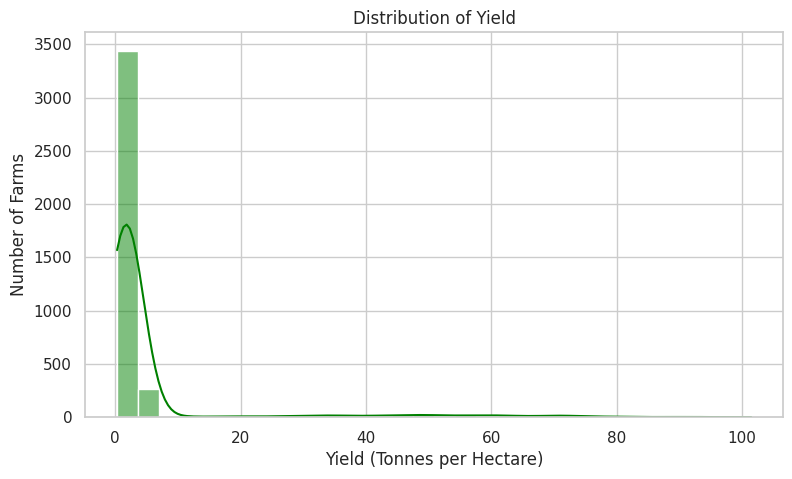

In [ ]:
# Distribution of yield

plt.figure(figsize=(9, 5))
sns.histplot(df["Yield_Tonnes_Ha"], bins=30, kde=True, color="green")
plt.title("Distribution of Yield")
plt.xlabel("Yield (Tonnes per Hectare)")
plt.ylabel("Number of Farms")
plt.show()

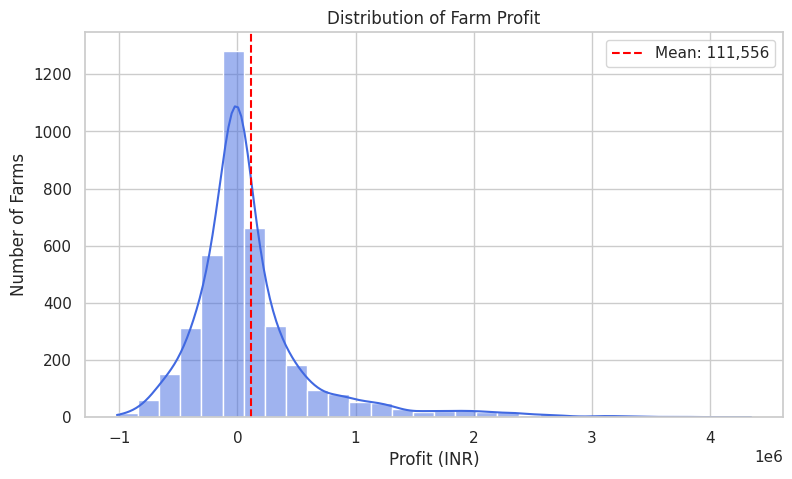

In [ ]:
# Distribution of profit

plt.figure(figsize=(9, 5))
sns.histplot(df["Profit_INR"], bins=30, kde=True, color="royalblue")
plt.axvline(df["Profit_INR"].mean(), color="red", linestyle="--",
            label=f"Mean: {df['Profit_INR'].mean():,.0f}")
plt.title("Distribution of Farm Profit")
plt.xlabel("Profit (INR)")
plt.ylabel("Number of Farms")
plt.legend()
plt.show()

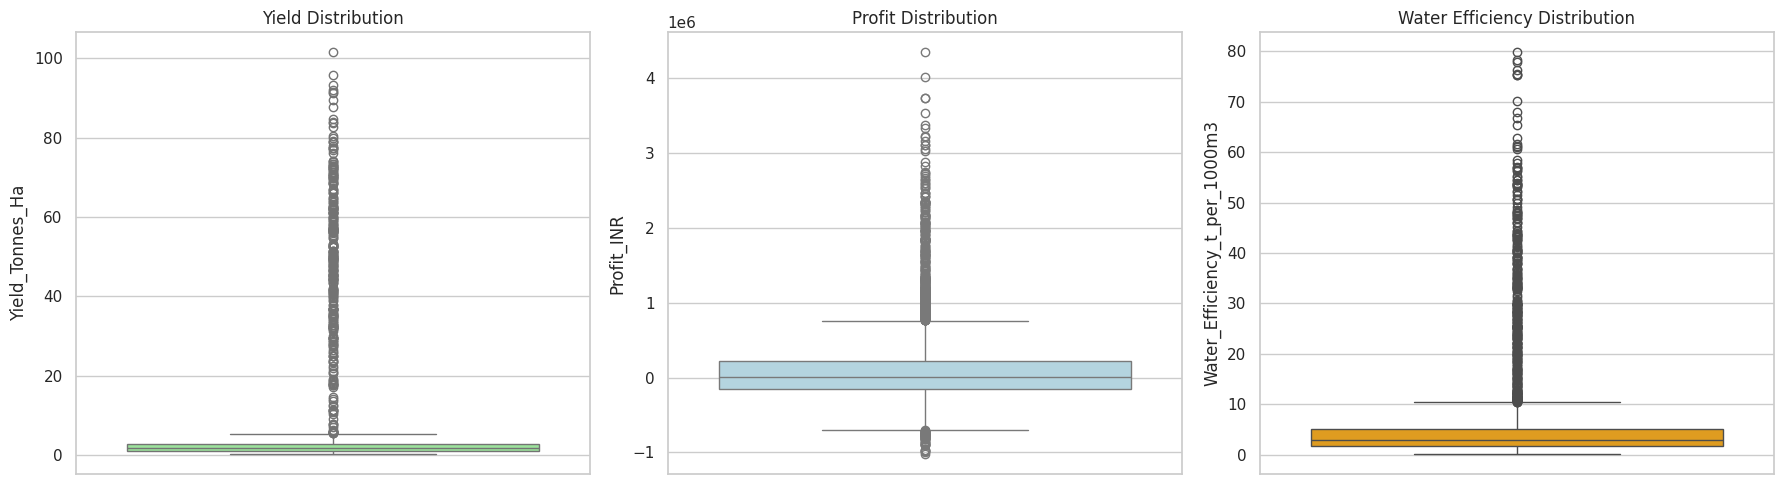

In [ ]:
# Boxplots for major performance indicators

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(y=df["Yield_Tonnes_Ha"], ax=axes[0], color="lightgreen")
axes[0].set_title("Yield Distribution")

sns.boxplot(y=df["Profit_INR"], ax=axes[1], color="lightblue")
axes[1].set_title("Profit Distribution")

sns.boxplot(y=df["Water_Efficiency_t_per_1000m3"], ax=axes[2], color="orange")
axes[2].set_title("Water Efficiency Distribution")

plt.tight_layout()
plt.show()

## 7. Seasonal Performance Analysis

In [ ]:
# Seasonal summary

seasonal_summary = df.groupby("Season").agg(
    Farms=("Farm_ID", "count"),
    Average_Yield=("Yield_Tonnes_Ha", "mean"),
    Average_Production=("Production_Tonnes", "mean"),
    Average_Revenue=("Revenue_INR", "mean"),
    Average_Profit=("Profit_INR", "mean"),
    Average_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean"),
    Average_Disease_Risk=("Disease_Pest_Risk_pct", "mean")
).sort_values("Average_Profit", ascending=False)

seasonal_summary

,Farms,Average_Yield,Average_Production,Average_Revenue,Average_Profit,Average_Water_Efficiency,Average_Disease_Risk
Season,,,,,,,
Kharif,1779,5.63,46.31,"710,719.06","178,914.65",5.89,54.47
Rabi,1627,5.04,41.49,"601,526.05","87,689.47",5.19,40.48
Zaid,594,4.64,38.89,"519,171.90","-24,804.82",4.41,38.22


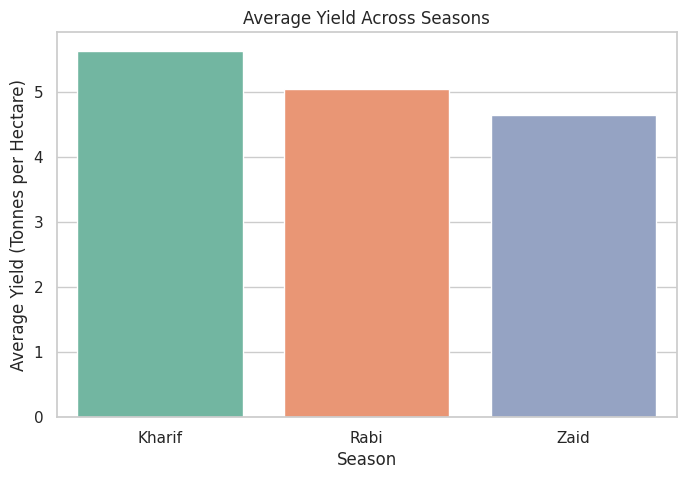

In [ ]:
# Average yield by season

plt.figure(figsize=(8, 5))
sns.barplot(
    data=df,
    x="Season",
    y="Yield_Tonnes_Ha",
    estimator=np.mean,
    errorbar=None,
    hue="Season",
    legend=False
)
plt.title("Average Yield Across Seasons")
plt.xlabel("Season")
plt.ylabel("Average Yield (Tonnes per Hectare)")
plt.show()

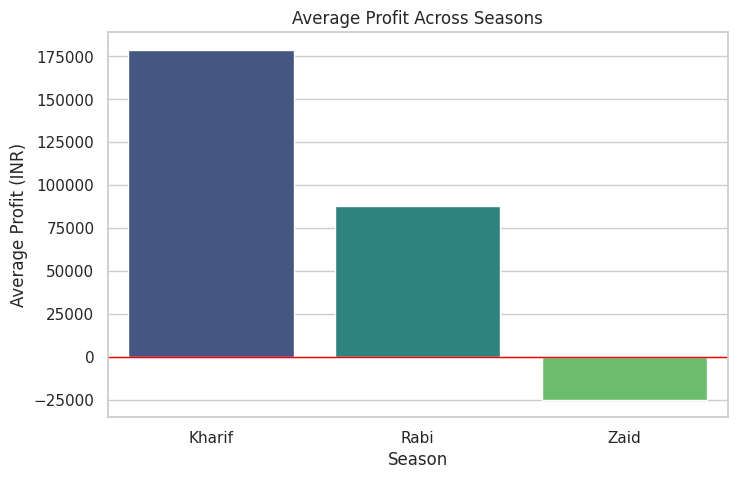

In [ ]:
# Average profit by season

plt.figure(figsize=(8, 5))
sns.barplot(
    data=df,
    x="Season",
    y="Profit_INR",
    estimator=np.mean,
    errorbar=None,
    hue="Season",
    legend=False,
    palette="viridis"
)
plt.axhline(0, color="red", linewidth=1)
plt.title("Average Profit Across Seasons")
plt.xlabel("Season")
plt.ylabel("Average Profit (INR)")
plt.show()

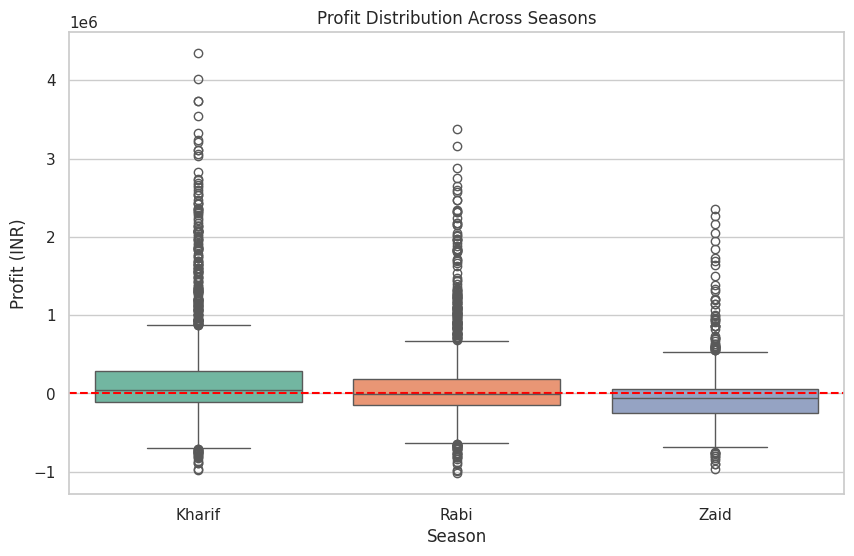

In [ ]:
# Profit distribution across seasons

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="Season", y="Profit_INR", hue="Season", legend=False)
plt.axhline(0, color="red", linestyle="--")
plt.title("Profit Distribution Across Seasons")
plt.xlabel("Season")
plt.ylabel("Profit (INR)")
plt.show()

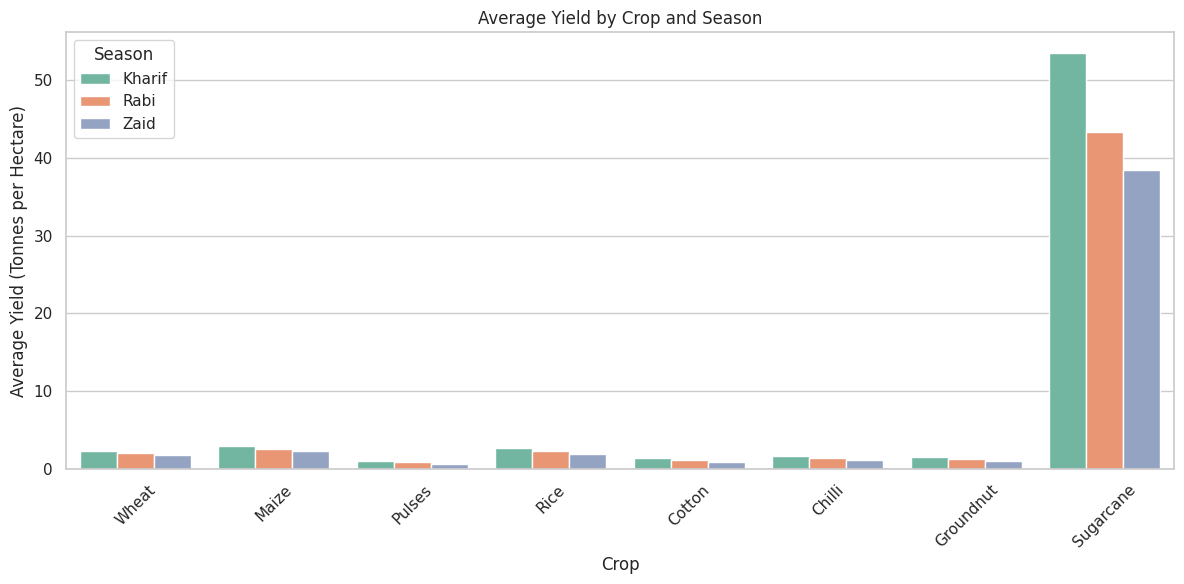

In [ ]:
# Yield comparison by season and crop

plt.figure(figsize=(12, 6))
sns.barplot(
    data=df,
    x="Crop",
    y="Yield_Tonnes_Ha",
    hue="Season",
    errorbar=None
)
plt.title("Average Yield by Crop and Season")
plt.xlabel("Crop")
plt.ylabel("Average Yield (Tonnes per Hectare)")
plt.xticks(rotation=45)
plt.legend(title="Season")
plt.tight_layout()
plt.show()

## 8. Crop and State-Wise Analysis

In [ ]:
# Crop-wise performance summary

crop_summary = df.groupby("Crop").agg(
    Farms=("Farm_ID", "count"),
    Average_Yield=("Yield_Tonnes_Ha", "mean"),
    Average_Profit=("Profit_INR", "mean"),
    Average_Revenue=("Revenue_INR", "mean"),
    Average_Production=("Production_Tonnes", "mean")
).sort_values("Average_Profit", ascending=False)

crop_summary

,Farms,Average_Yield,Average_Profit,Average_Revenue,Average_Production
Crop,,,,,
Sugarcane,305,46.64,"817,187.99","1,371,980.11",392.41
Chilli,412,1.54,"750,878.34","1,276,777.23",12.38
Cotton,508,1.23,"124,546.92","639,423.08",9.40
Groundnut,424,1.32,"44,858.12","542,935.50",9.66
Pulses,496,0.92,"-4,238.05","528,465.87",7.40
Maize,551,2.71,"-83,978.33","457,067.99",21.78
Rice,690,2.43,"-102,213.50","423,615.26",19.29
Wheat,614,2.11,"-123,398.34","400,104.89",16.85


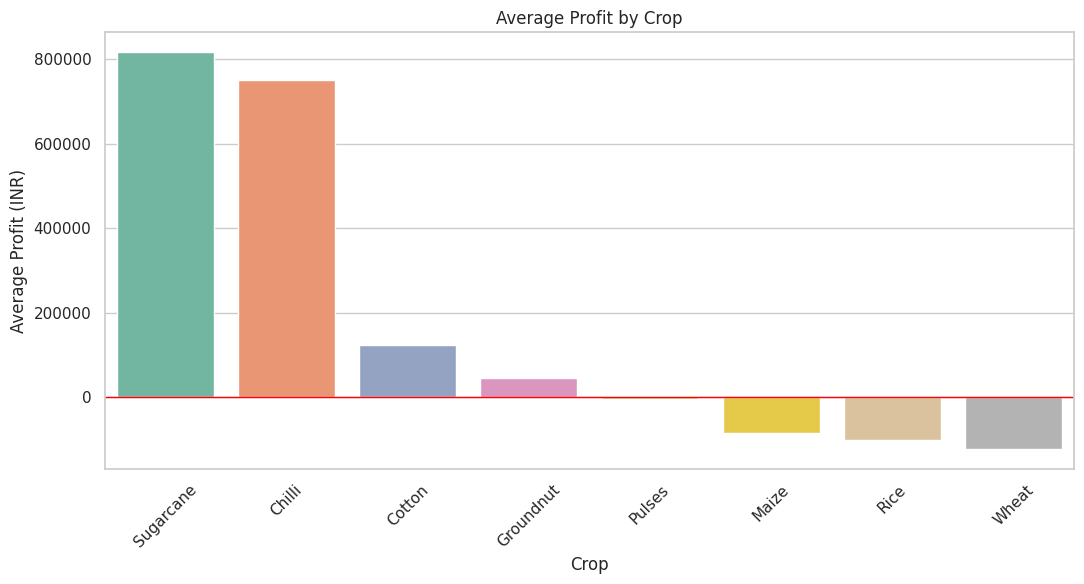

In [ ]:
# Crop-wise average profit

plt.figure(figsize=(11, 6))
crop_profit = df.groupby("Crop", as_index=False)["Profit_INR"].mean().sort_values(
    "Profit_INR", ascending=False
)

sns.barplot(data=crop_profit, x="Crop", y="Profit_INR", hue="Crop", legend=False)
plt.axhline(0, color="red", linewidth=1)
plt.title("Average Profit by Crop")
plt.xlabel("Crop")
plt.ylabel("Average Profit (INR)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Top states by average profit

state_summary = df.groupby("State").agg(
    Farms=("Farm_ID", "count"),
    Average_Yield=("Yield_Tonnes_Ha", "mean"),
    Average_Profit=("Profit_INR", "mean"),
    Average_Revenue=("Revenue_INR", "mean")
).sort_values("Average_Profit", ascending=False)

state_summary.head(10)

,Farms,Average_Yield,Average_Profit,Average_Revenue
State,,,,
Punjab,484,6.12,"136,025.64","686,225.70"
Maharashtra,512,5.02,"135,428.86","650,032.67"
Karnataka,489,5.69,"119,422.34","653,426.18"
Tamil Nadu,485,4.88,"117,744.75","629,093.42"
Gujarat,488,5.66,"117,568.24","654,692.86"
Telangana,516,5.04,"108,829.62","628,784.53"
Madhya Pradesh,497,4.99,"86,840.76","597,558.36"
Andhra Pradesh,529,4.63,"73,453.53","606,663.66"


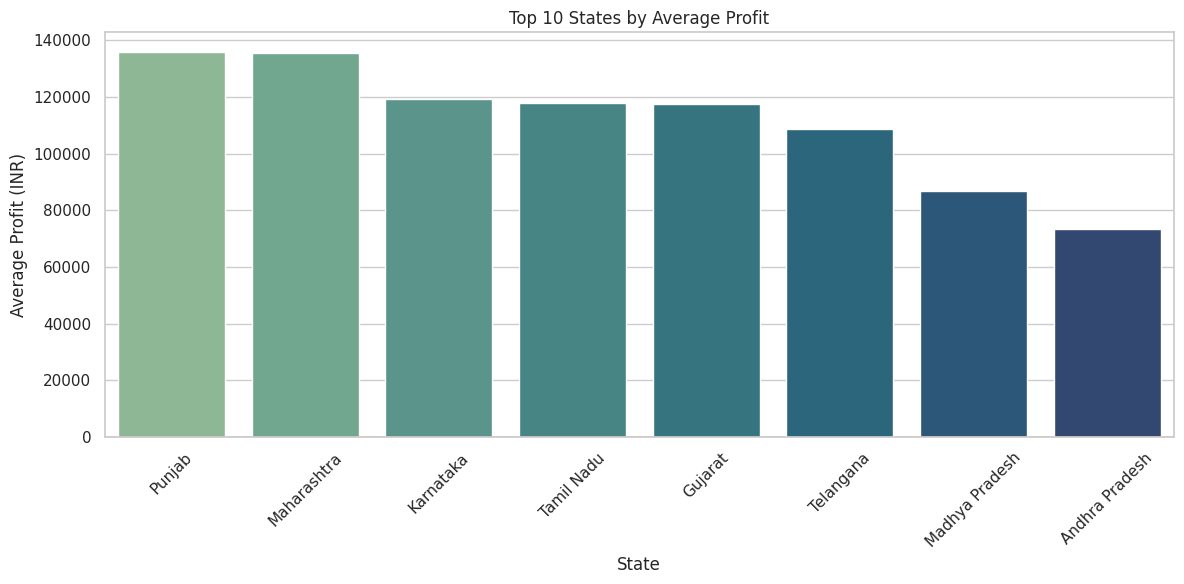

In [ ]:
# Top 10 states by average profit

top_states = state_summary.head(10).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(
    data=top_states,
    x="State",
    y="Average_Profit",
    hue="State",
    legend=False,
    palette="crest"
)
plt.axhline(0, color="red", linewidth=1)
plt.title("Top 10 States by Average Profit")
plt.xlabel("State")
plt.ylabel("Average Profit (INR)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 9. Bivariate Analysis

This section investigates relationships between environmental, resource-use and agricultural performance variables.

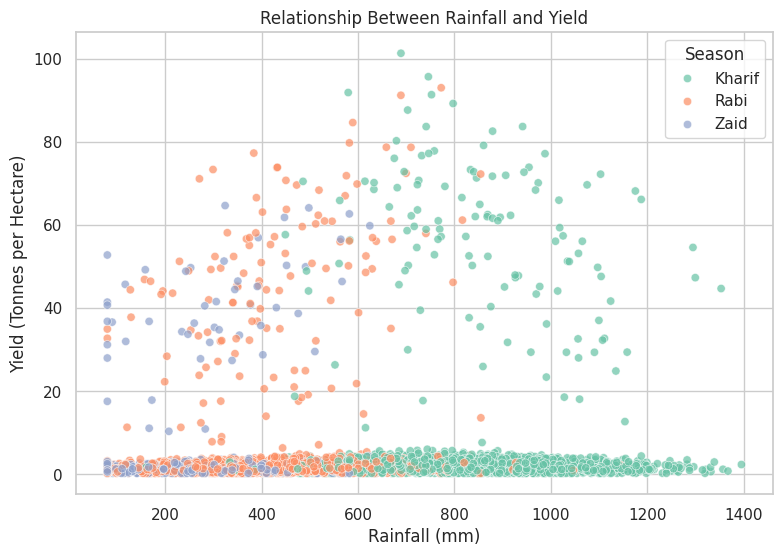

In [ ]:
# Rainfall and yield relationship

plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df,
    x="Rainfall_mm",
    y="Yield_Tonnes_Ha",
    hue="Season",
    alpha=0.7
)
plt.title("Relationship Between Rainfall and Yield")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (Tonnes per Hectare)")
plt.show()

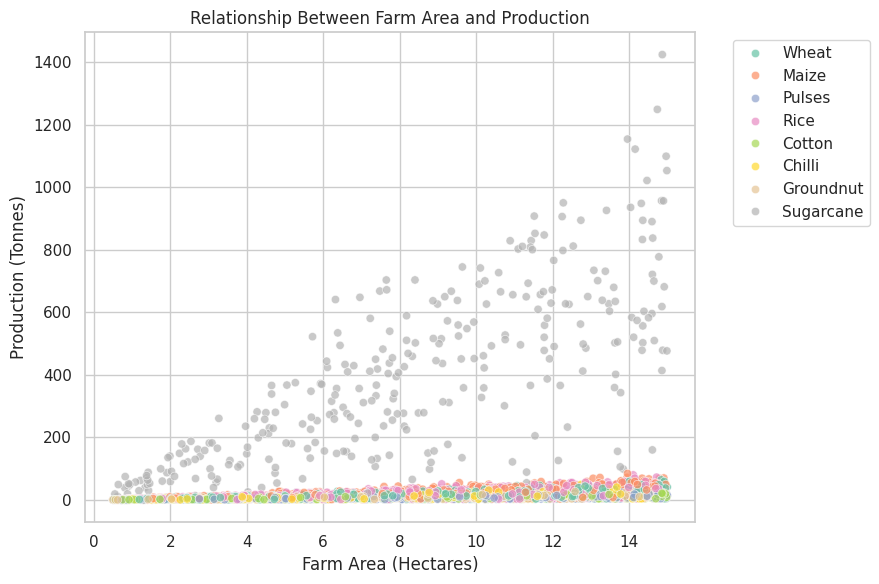

In [ ]:
# Farm area and production relationship

plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df,
    x="Farm_Area_Hectares",
    y="Production_Tonnes",
    hue="Crop",
    alpha=0.7
)
plt.title("Relationship Between Farm Area and Production")
plt.xlabel("Farm Area (Hectares)")
plt.ylabel("Production (Tonnes)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

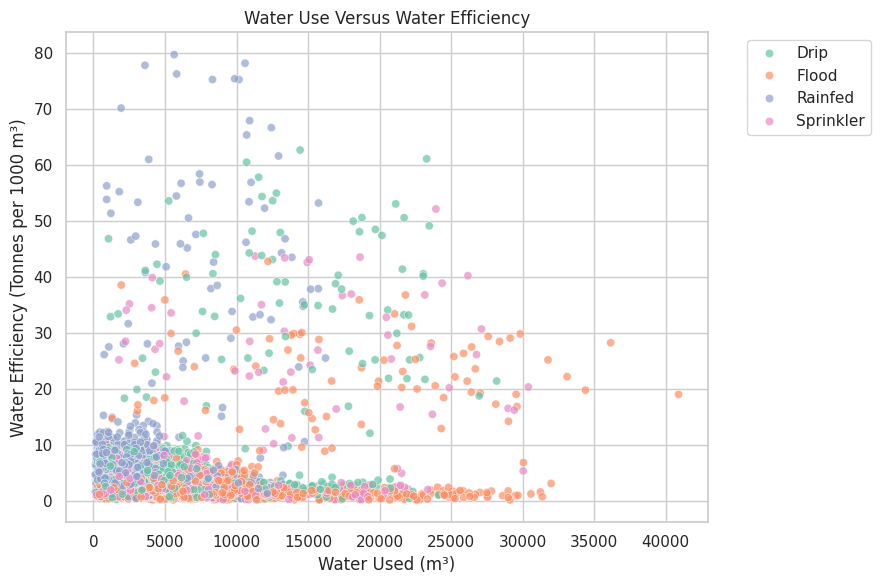

In [ ]:
# Water use and water efficiency relationship

plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df,
    x="Water_Used_m3",
    y="Water_Efficiency_t_per_1000m3",
    hue="Irrigation_Method",
    alpha=0.7
)
plt.title("Water Use Versus Water Efficiency")
plt.xlabel("Water Used (m³)")
plt.ylabel("Water Efficiency (Tonnes per 1000 m³)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [ ]:
# Irrigation method comparison

irrigation_summary = df.groupby("Irrigation_Method").agg(
    Average_Yield=("Yield_Tonnes_Ha", "mean"),
    Average_Profit=("Profit_INR", "mean"),
    Average_Water_Used=("Water_Used_m3", "mean"),
    Average_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean")
).sort_values("Average_Water_Efficiency", ascending=False)

irrigation_summary

,Average_Yield,Average_Profit,Average_Water_Used,Average_Water_Efficiency
Irrigation_Method,,,,
Rainfed,4.60,"79,050.37","3,549.55",7.56
Drip,6.58,"219,626.00","5,918.75",6.27
Sprinkler,5.16,"91,121.08","6,208.26",4.67
Flood,4.86,"73,354.02","8,026.47",3.44


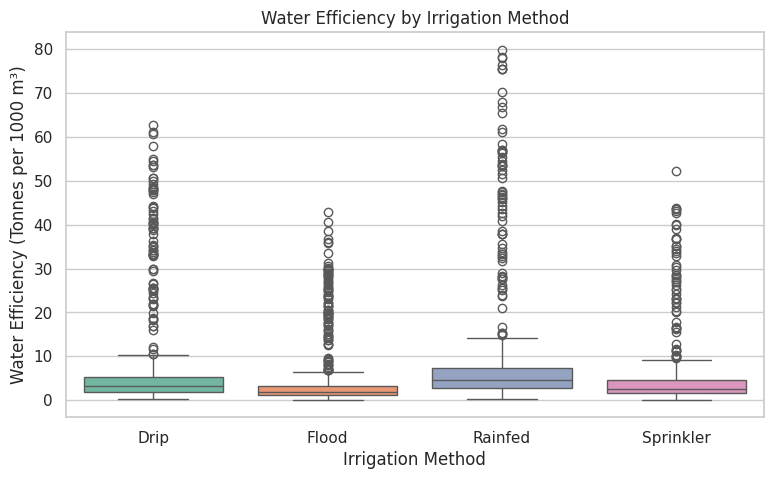

In [ ]:
# Water efficiency by irrigation method

plt.figure(figsize=(9, 5))
sns.boxplot(
    data=df,
    x="Irrigation_Method",
    y="Water_Efficiency_t_per_1000m3",
    hue="Irrigation_Method",
    legend=False
)
plt.title("Water Efficiency by Irrigation Method")
plt.xlabel("Irrigation Method")
plt.ylabel("Water Efficiency (Tonnes per 1000 m³)")
plt.show()

## 10. Multivariate Analysis: Correlation Heatmap

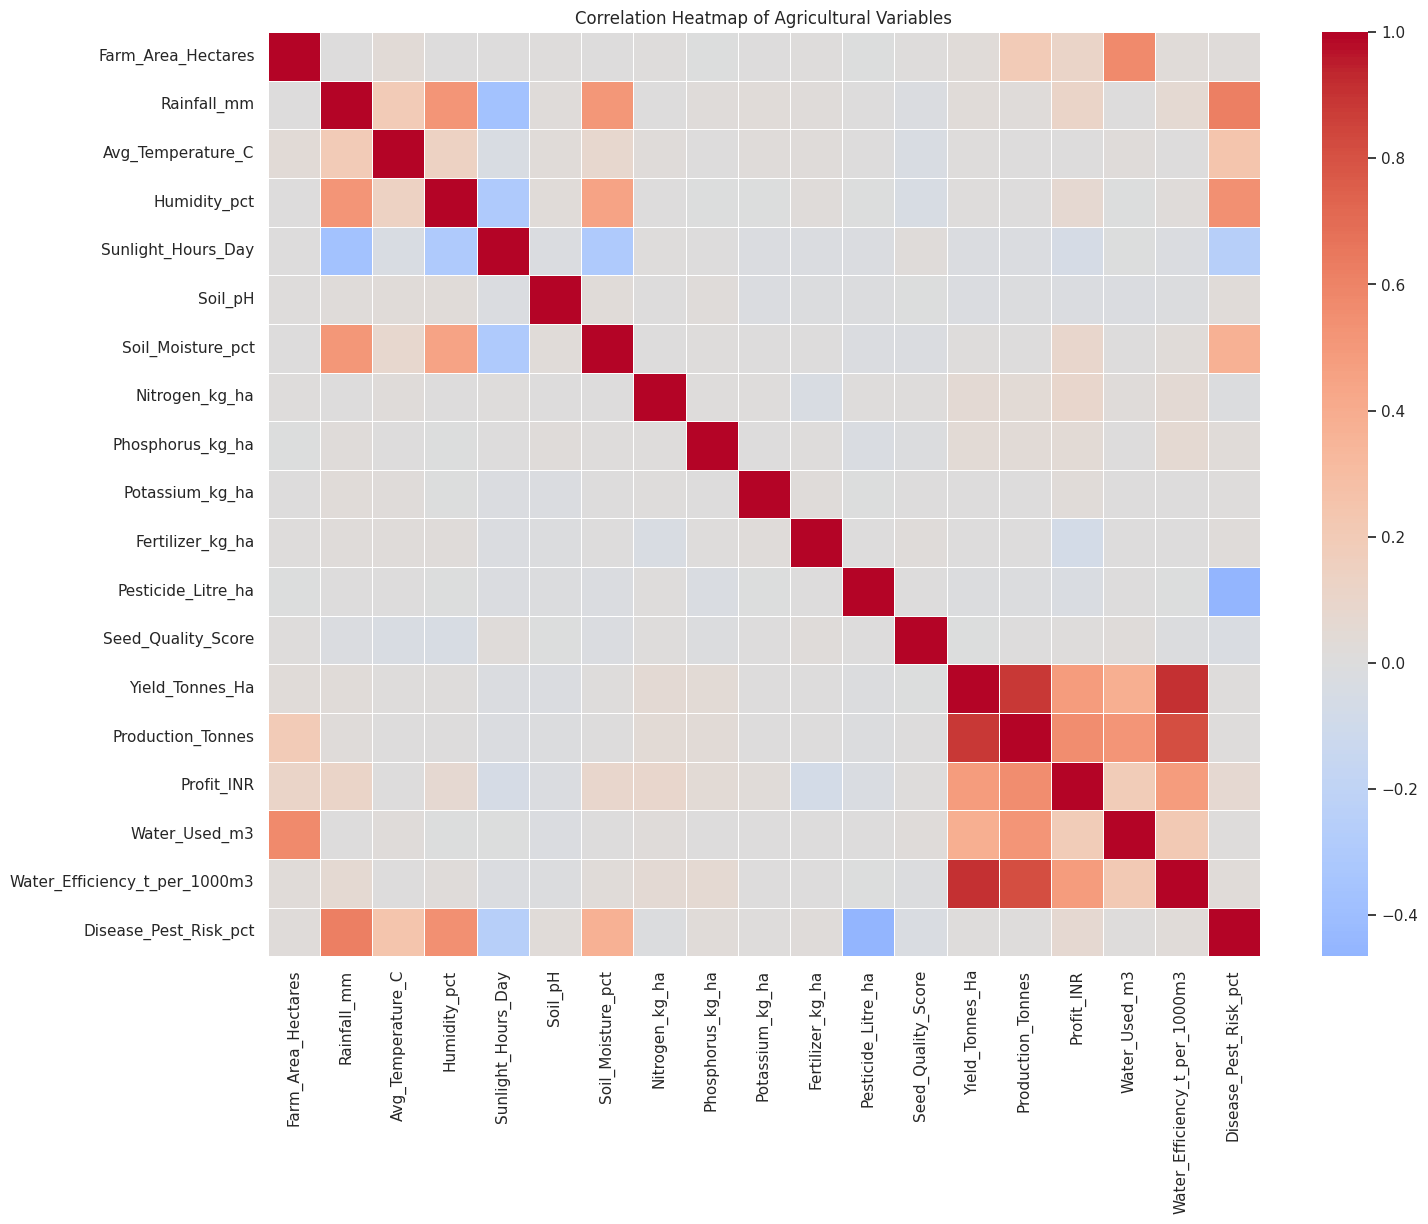

In [ ]:
# Select numerical variables for correlation analysis

correlation_columns = [
    "Farm_Area_Hectares",
    "Rainfall_mm",
    "Avg_Temperature_C",
    "Humidity_pct",
    "Sunlight_Hours_Day",
    "Soil_pH",
    "Soil_Moisture_pct",
    "Nitrogen_kg_ha",
    "Phosphorus_kg_ha",
    "Potassium_kg_ha",
    "Fertilizer_kg_ha",
    "Pesticide_Litre_ha",
    "Seed_Quality_Score",
    "Yield_Tonnes_Ha",
    "Production_Tonnes",
    "Profit_INR",
    "Water_Used_m3",
    "Water_Efficiency_t_per_1000m3",
    "Disease_Pest_Risk_pct"
]

corr_matrix = df[correlation_columns].corr()

plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, linewidths=0.4)
plt.title("Correlation Heatmap of Agricultural Variables")
plt.show()

In [ ]:
# Variables most correlated with yield

yield_correlations = (
    df[correlation_columns]
    .corr()["Yield_Tonnes_Ha"]
    .sort_values(ascending=False)
)

yield_correlations

,Yield_Tonnes_Ha
Yield_Tonnes_Ha,1.00
Water_Efficiency_t_per_1000m3,0.91
Production_Tonnes,0.88
Profit_INR,0.49
Water_Used_m3,0.39
Nitrogen_kg_ha,0.05
Phosphorus_kg_ha,0.05
Rainfall_mm,0.03
Farm_Area_Hectares,0.03
Disease_Pest_Risk_pct,0.01


## 11. Statistical Analysis

### Hypothesis

- Null Hypothesis (H0): Mean yield is the same across all seasons.
- Alternative Hypothesis (H1): At least one season has a different mean yield.

In [ ]:
# One-way ANOVA test: yield across seasons

season_groups = [
    group["Yield_Tonnes_Ha"].dropna()
    for _, group in df.groupby("Season")
]

anova_result = stats.f_oneway(*season_groups)

print("ANOVA Statistic:", round(anova_result.statistic, 4))
print("P-value:", round(anova_result.pvalue, 6))

if anova_result.pvalue < 0.05:
    print("Conclusion: Reject H0. Mean yield differs significantly across seasons.")
else:
    print("Conclusion: Fail to reject H0. No significant difference in mean yield across seasons.")

ANOVA Statistic: 1.5439
P-value: 0.213678
Conclusion: Fail to reject H0. No significant difference in mean yield across seasons.


In [ ]:
# Correlation test between rainfall and yield

correlation, p_value = stats.pearsonr(
    df["Rainfall_mm"],
    df["Yield_Tonnes_Ha"]
)

print("Pearson correlation coefficient:", round(correlation, 4))
print("P-value:", round(p_value, 6))

if p_value < 0.05:
    print("Conclusion: Rainfall and yield have a statistically significant relationship.")
else:
    print("Conclusion: No statistically significant relationship was found.")

Pearson correlation coefficient: 0.031
P-value: 0.050304
Conclusion: No statistically significant relationship was found.


## 12. Machine Learning: Yield Prediction

A Random Forest Regression model is used to predict farm yield based on environmental conditions, soil measures, farm inputs, location, crop and season.

In [ ]:
# Select features and target for yield prediction

target = "Yield_Tonnes_Ha"

features = [
    "State",
    "District",
    "Crop",
    "Season",
    "Farm_Area_Hectares",
    "Rainfall_mm",
    "Avg_Temperature_C",
    "Humidity_pct",
    "Sunlight_Hours_Day",
    "Soil_pH",
    "Soil_Moisture_pct",
    "Nitrogen_kg_ha",
    "Phosphorus_kg_ha",
    "Potassium_kg_ha",
    "Irrigation_Method",
    "Fertilizer_kg_ha",
    "Pesticide_Litre_ha",
    "Seed_Quality_Score",
    "Water_Used_m3",
    "Disease_Pest_Risk_pct"
]

X = df[features]
y = df[target]

categorical_features = X.select_dtypes(include="object").columns.tolist()
numerical_features = X.select_dtypes(include=np.number).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numerical_features),
    ("cat", categorical_transformer, categorical_features)
])

model = RandomForestRegressor(
    n_estimators=250,
    random_state=42,
    n_jobs=-1
)

yield_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", model)
])

yield_model.fit(X_train, y_train)

predictions = yield_model.predict(X_test)

mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print("Yield Prediction Model Performance")
print("MAE :", round(mae, 3))
print("RMSE:", round(rmse, 3))
print("R² Score:", round(r2, 3))

Yield Prediction Model Performance
MAE : 0.773
RMSE: 2.697
R² Score: 0.962


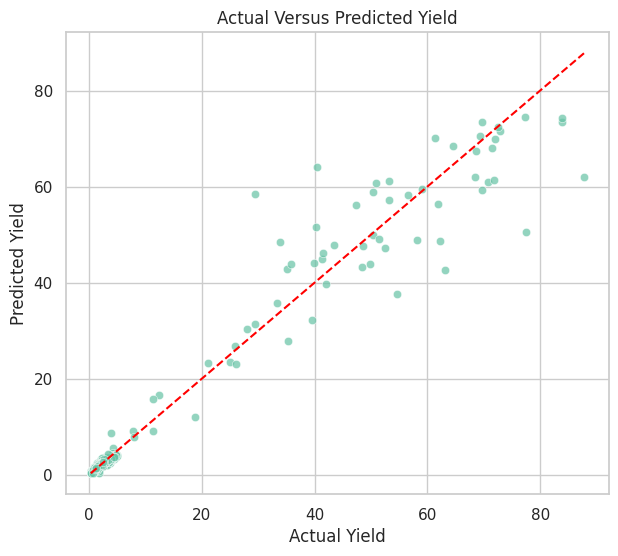

In [ ]:
# Actual versus predicted yield

results = pd.DataFrame({
    "Actual_Yield": y_test,
    "Predicted_Yield": predictions
})

plt.figure(figsize=(7, 6))
sns.scatterplot(data=results, x="Actual_Yield", y="Predicted_Yield", alpha=0.7)

minimum = min(results["Actual_Yield"].min(), results["Predicted_Yield"].min())
maximum = max(results["Actual_Yield"].max(), results["Predicted_Yield"].max())

plt.plot([minimum, maximum], [minimum, maximum], color="red", linestyle="--")
plt.title("Actual Versus Predicted Yield")
plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.show()

In [ ]:
# Identify most important numerical features from the trained model

feature_importance_model = yield_model.named_steps["model"]
processed_feature_names = yield_model.named_steps["preprocessor"].get_feature_names_out()

feature_importance = pd.DataFrame({
    "Feature": processed_feature_names,
    "Importance": feature_importance_model.feature_importances_
}).sort_values("Importance", ascending=False)

feature_importance.head(15)

,Feature,Importance
39,cat__Crop_Sugarcane,0.80
5,num__Soil_pH,0.14
1,num__Rainfall_mm,0.02
7,num__Nitrogen_kg_ha,0.01
9,num__Potassium_kg_ha,0.00
2,num__Avg_Temperature_C,0.00
10,num__Fertilizer_kg_ha,0.00
11,num__Pesticide_Litre_ha,0.00
12,num__Seed_Quality_Score,0.00
3,num__Humidity_pct,0.00


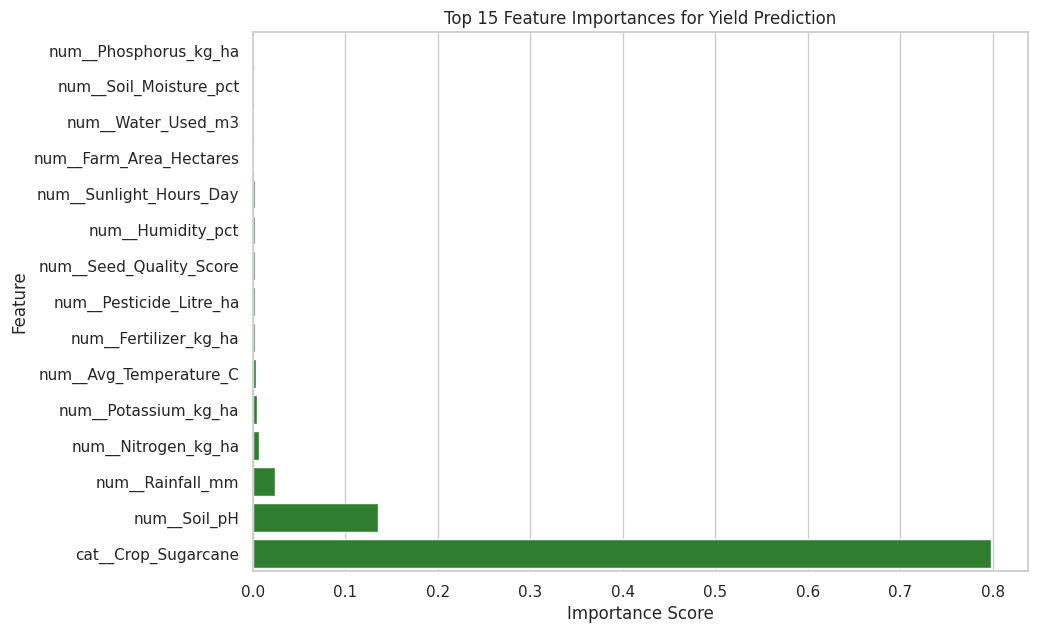

In [ ]:
# Plot top 15 important predictors of yield

top_features = feature_importance.head(15).sort_values("Importance")

plt.figure(figsize=(10, 7))
sns.barplot(data=top_features, x="Importance", y="Feature", color="forestgreen")
plt.title("Top 15 Feature Importances for Yield Prediction")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

## 13. Key Findings and Conclusion

The results below are generated directly from the dataset and can be used in the final project report.

In [ ]:
# Generate dataset-based findings automatically

best_season_yield = seasonal_summary["Average_Yield"].idxmax()
best_season_profit = seasonal_summary["Average_Profit"].idxmax()
best_crop_profit = crop_summary["Average_Profit"].idxmax()
best_state_profit = state_summary["Average_Profit"].idxmax()
best_irrigation = irrigation_summary["Average_Water_Efficiency"].idxmax()

print("KEY FINDINGS")
print("-" * 60)

print(f"1. {best_season_yield} has the highest average yield "
      f"({seasonal_summary.loc[best_season_yield, 'Average_Yield']:.2f} tonnes/hectare).")

print(f"2. {best_season_profit} has the highest average profit "
      f"(INR {seasonal_summary.loc[best_season_profit, 'Average_Profit']:,.2f}).")

print(f"3. {best_crop_profit} is the crop with the highest average profit "
      f"(INR {crop_summary.loc[best_crop_profit, 'Average_Profit']:,.2f}).")

print(f"4. {best_state_profit} has the highest average farm profit "
      f"(INR {state_summary.loc[best_state_profit, 'Average_Profit']:,.2f}).")

print(f"5. {best_irrigation} irrigation has the best average water efficiency "
      f"({irrigation_summary.loc[best_irrigation, 'Average_Water_Efficiency']:.2f} tonnes per 1000 m³).")

print(f"6. The yield prediction model achieved an R² score of {r2:.3f}.")

KEY FINDINGS
------------------------------------------------------------
1. Kharif has the highest average yield (5.63 tonnes/hectare).
2. Kharif has the highest average profit (INR 178,914.65).
3. Sugarcane is the crop with the highest average profit (INR 817,187.99).
4. Punjab has the highest average farm profit (INR 136,025.64).
5. Rainfed irrigation has the best average water efficiency (7.56 tonnes per 1000 m³).
6. The yield prediction model achieved an R² score of 0.962.


## 14. Recommendations

Based on the analysis, the following recommendations can be considered:

1. Promote the crops and seasonal practices associated with higher yield and profit.
2. Encourage irrigation methods with greater water efficiency, especially in water-scarce regions.
3. Improve soil nutrient management by monitoring nitrogen, phosphorus and potassium levels.
4. Use weather-related variables such as rainfall, temperature and humidity to plan crop selection.
5. Prioritize disease and pest management in farms with high disease-risk percentages.
6. Use the yield prediction model to support farm planning and resource allocation.
7. Focus on states and crops with consistently low profitability to identify cost-reduction opportunities.

## 15. Outlier Investigation

Outliers were investigated using the Interquartile Range (IQR) method. This method identifies unusually low or high values that fall below Q1 − 1.5 × IQR or above Q3 + 1.5 × IQR.

Outliers are not automatically removed because they may represent genuine farm-level variations. They are retained unless they are found to be data-entry errors.

In [ ]:
# Investigate outliers using the IQR method

outlier_columns = [
    "Farm_Area_Hectares",
    "Rainfall_mm",
    "Yield_Tonnes_Ha",
    "Production_Tonnes",
    "Revenue_INR",
    "Profit_INR",
    "Water_Used_m3",
    "Water_Efficiency_t_per_1000m3"
]

outlier_summary = []

for column in outlier_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outlier_count = ((df[column] < lower_limit) | (df[column] > upper_limit)).sum()

    outlier_summary.append({
        "Variable": column,
        "Lower Limit": lower_limit,
        "Upper Limit": upper_limit,
        "Outlier Count": outlier_count
    })

outlier_df = pd.DataFrame(outlier_summary)
outlier_df

,Variable,Lower Limit,Upper Limit,Outlier Count
0,Farm_Area_Hectares,-6.83,22.73,0
1,Rainfall_mm,-319.02,"1,522.57",0
2,Yield_Tonnes_Ha,-1.62,5.50,302
3,Production_Tonnes,-23.98,53.36,333
4,Revenue_INR,"-736,519.00","1,780,911.00",240
5,Profit_INR,"-696,111.00","763,567.00",404
6,Water_Used_m3,"-6,072.75","16,171.25",276
7,Water_Efficiency_t_per_1000m3,-3.57,10.38,322


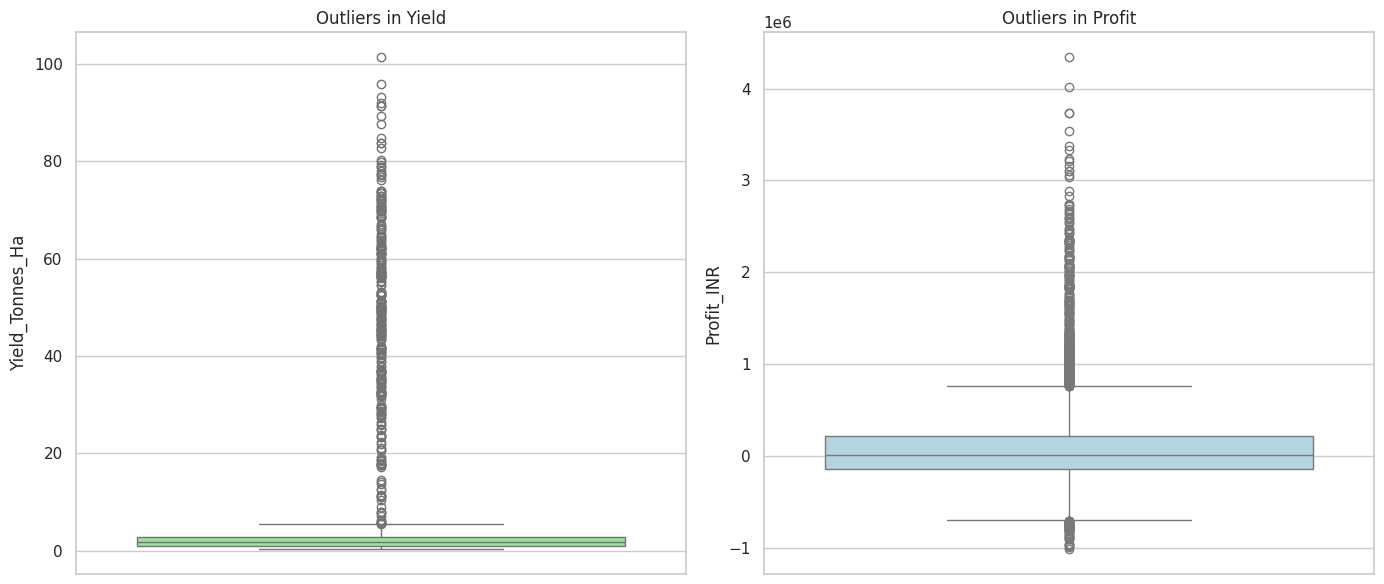

In [ ]:
# Visualize outliers in major performance variables

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.boxplot(y=df["Yield_Tonnes_Ha"], color="lightgreen")
plt.title("Outliers in Yield")

plt.subplot(1, 2, 2)
sns.boxplot(y=df["Profit_INR"], color="lightblue")
plt.title("Outliers in Profit")

plt.tight_layout()
plt.show()

## 16. Key Insights

The following insights are generated directly from the dataset. They summarize seasonal, crop-wise, state-wise, irrigation-wise and financial performance.

In [ ]:
# Generate at least eight meaningful insights from the analysis

worst_season_profit = seasonal_summary["Average_Profit"].idxmin()
best_crop_yield = crop_summary["Average_Yield"].idxmax()
worst_crop_profit = crop_summary["Average_Profit"].idxmin()
worst_state_profit = state_summary["Average_Profit"].idxmin()

profitable_farms_pct = (df["Profit_INR"] > 0).mean() * 100
loss_making_farms_pct = (df["Profit_INR"] < 0).mean() * 100

highest_disease_season = (
    df.groupby("Season")["Disease_Pest_Risk_pct"]
    .mean()
    .idxmax()
)

top_yield_factor = (
    yield_correlations.drop("Yield_Tonnes_Ha")
    .abs()
    .idxmax()
)

top_yield_correlation = yield_correlations[top_yield_factor]

print("EIGHT MEANINGFUL INSIGHTS")
print("-" * 70)

print(f"1. {best_season_yield} has the highest average yield "
      f"of {seasonal_summary.loc[best_season_yield, 'Average_Yield']:.2f} tonnes per hectare.")

print(f"2. {best_season_profit} has the highest average profit "
      f"of INR {seasonal_summary.loc[best_season_profit, 'Average_Profit']:,.2f}.")

print(f"3. {worst_season_profit} has the lowest average profit "
      f"of INR {seasonal_summary.loc[worst_season_profit, 'Average_Profit']:,.2f}.")

print(f"4. {best_crop_yield} has the highest average yield among the crops "
      f"at {crop_summary.loc[best_crop_yield, 'Average_Yield']:.2f} tonnes per hectare.")

print(f"5. {best_crop_profit} has the highest average crop profit "
      f"of INR {crop_summary.loc[best_crop_profit, 'Average_Profit']:,.2f}.")

print(f"6. {best_state_profit} has the highest average state-level farm profit "
      f"of INR {state_summary.loc[best_state_profit, 'Average_Profit']:,.2f}.")

print(f"7. {best_irrigation} irrigation has the highest water efficiency "
      f"at {irrigation_summary.loc[best_irrigation, 'Average_Water_Efficiency']:.2f} tonnes per 1000 m³.")

print(f"8. {highest_disease_season} has the highest average disease/pest risk.")

print(f"\nAdditional finding: {profitable_farms_pct:.2f}% of farms are profitable, "
      f"while {loss_making_farms_pct:.2f}% are loss-making.")

print(f"Additional finding: {top_yield_factor} has the strongest correlation "
      f"with yield among the analysed numerical variables "
      f"(correlation = {top_yield_correlation:.3f}).")

EIGHT MEANINGFUL INSIGHTS
----------------------------------------------------------------------
1. Kharif has the highest average yield of 5.63 tonnes per hectare.
2. Kharif has the highest average profit of INR 178,914.65.
3. Zaid has the lowest average profit of INR -24,804.82.
4. Sugarcane has the highest average yield among the crops at 46.64 tonnes per hectare.
5. Sugarcane has the highest average crop profit of INR 817,187.99.
6. Punjab has the highest average state-level farm profit of INR 136,025.64.
7. Rainfed irrigation has the highest water efficiency at 7.56 tonnes per 1000 m³.
8. Kharif has the highest average disease/pest risk.

Additional finding: 50.85% of farms are profitable, while 49.15% are loss-making.
Additional finding: Water_Efficiency_t_per_1000m3 has the strongest correlation with yield among the analysed numerical variables (correlation = 0.913).


## 17. Limitations of the Analysis

This analysis has the following limitations:

1. The dataset may be simulated or may not represent every agricultural region in India.
2. The dataset does not include multiple years; therefore, long-term trends and annual weather changes cannot be studied.
3. Farm profitability can be influenced by external factors such as transport costs, government subsidies, storage facilities and market demand, which may not be fully captured.
4. Correlation does not prove causation. A variable correlated with yield may not necessarily be the direct cause of higher or lower yield.
5. Outliers were retained because they may represent valid farm conditions; however, they can influence average values.
6. The machine-learning model is based only on the available variables and may perform differently on real-world future data.

## 18. Final Conclusion

This project analyzed seasonal agricultural performance using farm-level data related to crops, climate, soil, irrigation, inputs, production, revenue, profit and water usage.

The analysis showed that agricultural performance varies across seasons, crops, states and irrigation methods. Seasonal comparisons identified differences in yield and profitability, while crop-wise and state-wise analysis highlighted high-performing and low-performing groups. The correlation analysis and machine-learning model helped identify variables associated with yield performance.

The findings can support better agricultural decision-making by helping farmers and policymakers select suitable crops, improve water management, plan resource use and reduce financial losses. However, the results should be interpreted considering the limitations of the dataset and the fact that agricultural performance is affected by several external factors.